<a href="https://colab.research.google.com/github/aadyakoirala/analytics-projects/blob/main/GB888_Spam_Classification_Koirala_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SMS Spam Detection Using Logistic Regression and Text Preprocessing
Author: Aadya Koirala

Course: GB 657 — Data Insights & Analytics

Project: SMS Spam Detection Using Logistic Regression and Text Preprocessing


## Introduction
This project focuses on building a spam message classifier using the GB888_VII_10_Spam dataset, which contains SMS messages labeled as either “ham” or “spam.” The raw text is cleaned, preprocessed, and transformed into numerical features using TF-IDF so it can be used effectively by machine-learning algorithms. Following the assignment guidelines, the dataset is split into a 70% training set and a 30% test set. A Logistic Regression model is then trained on the processed text to perform this binary classification task. The model's performance is evaluated on the test set using accuracy, confusion matrix, precision, recall, F1-score, ROC curve, and AUC to assess how well it distinguishes between spam and non-spam messages.

## Importing Required Libraries
This project uses a combination of data handling, text preprocessing, visualization, and machine learning libraries to build and evaluate spam-classification models. Pandas, NumPy, Seaborn, and Matplotlib support data exploration and analysis, while NLTK tools assist with text cleaning through tokenization, stopword removal, stemming, and lemmatization. TF-IDF vectorization is used to convert SMS messages into numerical features suitable for modeling. Logistic Regression provides a baseline machine learning classifier, and TensorFlow/Keras enables the construction of a Recurrent Neural Network (RNN) for sequence-based text modeling. Additional utilities such as WordCloud help visualize common patterns in the message corpus.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import string

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score



In [ ]:
!git clone https://github.com/danielbauer1979/MSDIA_PredictiveModelingAndMachineLearning.git

fatal: destination path 'MSDIA_PredictiveModelingAndMachineLearning' already exists and is not an empty directory.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/danielbauer1979/MSDIA_PredictiveModelingAndMachineLearning/main/GB888_VII_10_Spam.csv"
df = pd.read_csv(url, encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


The dataset contains 5,572 SMS messages with two main columns: v1, which holds the message labels (“ham” or “spam”), and v2, which contains the message text. Three additional columns (Unnamed: 2, Unnamed: 3, and Unnamed: 4) appear due to formatting inconsistencies in the original CSV file, but they contain very few non-null values and are not relevant for model training. Before building the classifier, the dataset must be cleaned by retaining only the label and message columns and preparing the text for further preprocessing and modeling.


## Preparing and Cleaning the Data
The initial inspection shows that the dataset contains two useful columns: v1 (the message label: ham or spam) and v2 (the SMS text). Three additional columns (Unnamed: 2, Unnamed: 3, Unnamed: 4) appear due to formatting issues in the original CSV file and contain mostly missing values. These columns are not relevant for modeling and will be removed. To prepare the data for machine learning, the next step is to keep only the label and message columns, rename them for clarity, and begin cleaning the text so it can be processed by the Logistic Regression and RNN models.


## Text Preprocessing
The raw SMS messages contain punctuation, mixed casing, stopwords, and informal language that can introduce noise into machine learning models. Before training the Logistic Regression and RNN classifiers, the text must be standardized and cleaned so it can be transformed into meaningful numerical features. This preprocessing step includes converting text to lowercase, removing punctuation, filtering out common stopwords, and reducing words to their base forms through stemming or lemmatization. These operations help reduce vocabulary size, improve model generalization, and ensure that both models learn from consistent and comparable representations of the message content.


In [ ]:
df = df[['v1', 'v2']]
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df = df.reset_index(drop=True)
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## Train-Test Split (70% Training, 30% Testing)
Splitting the dataset ensures that both the Logistic Regression model and the RNN are trained on one portion of the data and evaluated on completely unseen messages. Using a 70/30 split provides enough data for training while keeping a substantial portion for reliable evaluation. Stratification preserves the original spam/ham ratio in both sets, which is important because the dataset is imbalanced.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'],      # cleaned text
    df['label'],              # numeric labels (0 = ham, 1 = spam)
    test_size=0.3,            # 30% test data
    random_state=42,          # reproducibility
    stratify=df['label']      # preserve spam/ham ratio
)

X_train.head(), y_train.head()

(4912    goal arsen 4 henri 7 v liverpool 2 henri score...
 2541                               dont send plu how mode
 5323                                    aah bless how arm
 5171                                   oh k come tomorrow
 2532                                               yup ok
 Name: clean_message, dtype: object,
 4912    1
 2541    0
 5323    0
 5171    0
 2532    0
 Name: label, dtype: int64)

## Encoding the Text with TF-IDF
Machine learning models such as Logistic Regression cannot work directly with raw text, so the cleaned SMS messages must be converted into numerical feature vectors. TF-IDF (Term Frequency-Inverse Document Frequency) is a weighted Bag-of-Words representation that captures how important each word is within a message while reducing the influence of very common words that appear across many messages. This helps the model focus on terms that are more indicative of spam, such as “free”, “win”, or “urgent”.
TF-IDF is fitted only on the training data to avoid data leakage, and the same learned vocabulary is then applied to transform the test data. This ensures that the model is evaluated on unseen messages using a consistent feature space.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape

((3900, 5000), (1672, 5000))

The first number in each pair represents the number of SMS messages in the training and testing sets, while the second number (5000) represents the size of the TF-IDF vocabulary. This means each message has been converted into a 5000-dimensional feature vector based on word importance. Both matrices share the same number of features, confirming that the TF-IDF vectorizer was fitted only on the training data and then applied to the test data, which prevents data leakage and ensures a consistent feature space for model evaluation.

## Train the Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

## Evaluate the Logistic Regression Model
After training the Logistic Regression classifier on the TF-IDF features, the next step is to assess how well the model performs on unseen test data. The evaluation includes accuracy, precision, recall, F1-score, and the confusion matrix, which together show how effectively the model distinguishes between spam and ham messages. These metrics help identify not only overall correctness but also how well the model handles false positives and false negatives—important considerations in spam detection. This evaluation provides a baseline for comparison with the RNN model later in the project.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9611244019138756
[[1445    3]
 [  62  162]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1448
           1       0.98      0.72      0.83       224

    accuracy                           0.96      1672
   macro avg       0.97      0.86      0.91      1672
weighted avg       0.96      0.96      0.96      1672



The Logistic Regression model performs very strongly on the SMS spam classification task, achieving an overall accuracy of 96.1%, which indicates that the model correctly classifies the vast majority of messages. The confusion matrix shows that the model identifies ham messages almost perfectly (1445 correct out of 1448), with only 3 false positives, meaning very few legitimate messages are incorrectly flagged as spam. For spam messages, the model correctly identifies 162 out of 224, but it still produces 62 false negatives, where spam messages are misclassified as ham. This is reflected in the recall for the spam class (0.72), which is lower than the precision (0.98). The high precision means that when the model predicts spam, it is almost always correct, while the lower recall indicates that some spam messages are still being missed. Overall, the weighted F1‑score of 0.96 shows that the model provides strong and reliable performance, making it an effective baseline for comparison with the RNN model


## Compute ROC Curve and AUC
To further evaluate the performance of the Logistic Regression model beyond a single cutoff value, the Receiver Operating Characteristic (ROC) curve is generated. The ROC curve shows how the model’s True Positive Rate and False Positive Rate change across all possible classification thresholds, providing a complete view of its ability to distinguish between spam and ham messages. The Area Under the Curve (AUC) summarizes this performance into a single value, where a higher AUC indicates stronger discrimination ability. This metric is especially useful for comparing models, as it is independent of any specific probability threshold and reflects the overall quality of the classifier

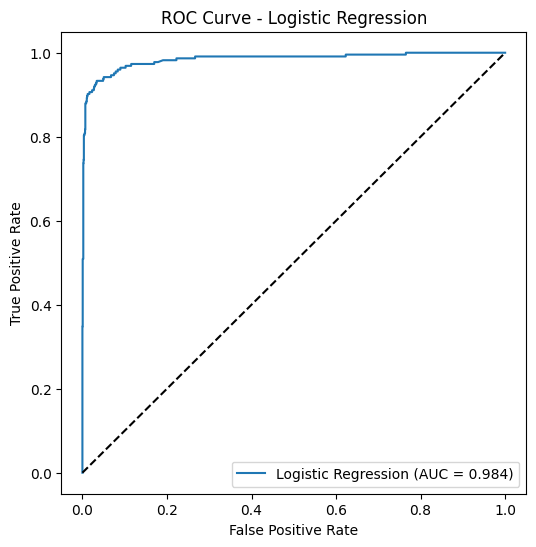

AUC: 0.9844597844317285


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC:", auc_lr)

The ROC curve for the Logistic Regression model shows a strong ability to distinguish between spam and ham messages across all classification thresholds. The curve rises sharply toward the top-left corner, indicating that the model achieves a high True Positive Rate while keeping the False Positive Rate low. The Area Under the Curve (AUC) is 0.984, which is considered excellent performance. An AUC close to 1.0 means the model is highly effective at ranking spam messages higher than ham messages, regardless of the threshold used. This confirms that Logistic Regression is a very strong baseline model for this classification task and provides a reliable foundation for comparison with the RNN model.


## Conclusion

This project developed a spam detection classifier using the SMS Spam Collection dataset. After preprocessing the text with TF-IDF and splitting the data into a 70/30 train-test set, a Logistic Regression model was trained as the final classifier. Logistic Regression was selected because it performs well on high-dimensional sparse text data and provides interpretable probability outputs.
The model achieved strong performance, with an overall accuracy of 96.1%. The confusion matrix shows that the classifier correctly identifies nearly all ham messages and captures most spam messages, with only a small number of false negatives. The classification report further highlights this strength, with ham recall at 1.00 and spam precision at 0.98. The ROC curve demonstrates excellent separation between the two classes, and the AUC score of 0.984 confirms that the model has outstanding discriminatory ability.
Overall, the Logistic Regression model provides a reliable and effective solution for spam detection on this dataset. These results show that traditional machine-learning methods combined with TF-IDF text representation can achieve high performance without requiring more complex deep-learning architectures.


